# Diffusion 기반 DAG Topological Ordering — 과정과 결과 정리

단일하게 학습된 **full-dimensional DDPM 하나**로부터 DAG의 **topological order**를 복원하는
실험 파이프라인의 정리 노트북입니다.

> **핵심 주의사항 (먼저 읽어주세요)**
> 1. 이 방법은 **순서(order)** 를 추정합니다. **sparse DAG 구조(skeleton)를 추정하지 않습니다.**
>    출력의 `fully_connected_order_dag` 는 추정된 순서를 인코딩한 *완전 그래프*일 뿐입니다.
>    따라서 SHD / edge-F1 은 **의도적으로 보고하지 않습니다.**
> 2. SCORE 정리("nonlinear ANM의 leaf는 diagonal score Hessian이 상수")는 **t=0 (clean density)** 에서의 결과입니다.
>    본 구현은 **t_order > 0** 인 noised density에서 기준을 평가하므로, **실험적(experimental)** 이며
>    t=0 보장이 자동으로 따라오지 않습니다.
> 3. 아래 결과는 **D=3 짜리 예제 하나**에 대한 것으로, 방법론의 일반적 검증이 아닙니다.

---

## 1. 문제 설정과 수식

DDPM forward process:

$$X_t = \sqrt{\bar\alpha_t}\,X_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\qquad m_t=\sqrt{\bar\alpha_t},\quad \sigma_t^2 = 1-\bar\alpha_t$$

남은 변수 집합 $S$ 에 대해, noised marginal의 Hessian을 **Tweedie 항등식**으로 구합니다:

$$H_S(x_S,t)=\nabla^2_{x_S}\log p_{t,S}(x_S)
=\frac{\bar\alpha_t}{\sigma_t^{4}}\,\mathrm{Cov}\!\left(X_{0,S}\mid X_{t,S}=x_S\right)-\frac{1}{\sigma_t^{2}}I_{|S|}$$

**단위 주의:** 코드에서는 `sigma2_t = 1 - alpha_bar_t` 이므로, 수식의 $\sigma_t^4$ 는
코드에서 **`sigma2_t ** 2`** 입니다 (`sigma2_t ** 4` 아님). 이 부분은 테스트로 고정해 두었습니다.

각 $i\in S$ 에 대해 **anchor들 간의 분산**을 leaf 점수로 사용합니다:

$$V_i(S,t)=\mathrm{Var}_{U_S\sim p_{t,S}}\big[H_{ii,S}(U_S,t)\big],
\qquad \mathrm{leaf}(S)=\arg\min_{i\in S} V_i(S,t)$$

제거 순서가 `leaf_order` (sink부터), 최종 결과는 `topological_order = reverse(leaf_order)` 입니다.
$H$ 에 **절댓값을 취하지 않습니다** — 부호가 있는 diagonal 값의 분산을 씁니다.

## 2. 왜 conditional sampling이 필요한가

학습된 DDPM은 **full-dimensional score만** 제공합니다:

$$s_\theta(x_t,t)\approx\nabla_{x_t}\log p_t(x_t)$$

그런데 우리는 부분집합 $S$ 의 marginal $p_{t,S}$ 의 Hessian이 필요합니다.
$R=\{1..D\}\setminus S$ 라 할 때 핵심은 다음 항등식입니다:

$$\nabla_{x_R}\log p_t(x_R\mid x_S)=\nabla_{x_R}\log p_t(x_R,x_S)$$

즉 **$x_S$ 를 고정한 채 full score의 $R$ 성분만 떼어 쓰면** 조건부 score가 됩니다.
→ **재학습이 전혀 필요 없습니다.**

그래서 anchor $x_{t,S}$ 마다 2단계로 $X_{0,S}\mid X_{t,S}$ 를 근사합니다:

| 단계 | 내용 |
|---|---|
| **Stage A** | fixed-time Langevin(ULA)로 $x_{t,R}\sim p_t(x_R\mid x_{t,S})$ 샘플링 |
| **Stage B** | $x_{t,S}$ 와 병합해 **D차원 전체** 상태를 만들고 $t\to0$ 역확산, $x_0$ 의 $S$ 성분만 보관 |

ULA 업데이트: $z_{k+1}=z_k+h\,\mathrm{score}_R(\mathrm{merge}(x_S,z_k),t)+\sqrt{2h}\,\xi_k$

> **구현상 중요한 예외**: 첫 stage에서는 $S=\{1..D\}$ 이라 $R=\emptyset$ 입니다.
> Langevin을 돌릴 것이 없으므로 **건너뛰고**, 대신 독립적인 역확산 궤적 수로 샘플 예산을 채웁니다.

## 3. 모듈 구조

```
models/dag_diffusion/
├── score_adapter.py        # eps/x_0 예측망 → score 변환 (+ 검증)
├── conditional_langevin.py # Stage A: X_{t,R} | X_{t,S} ULA 샘플러
├── reverse_posterior.py    # Stage B: 역확산 + 2단계 결합 샘플러
├── moments.py              # Welford 스트리밍 공분산 (대용량 M 대응)
├── tweedie_hessian.py      # Tweedie 공식 (full + diagonal)
├── ordering.py             # 순차 leaf 제거 알고리즘
├── diagnostics.py          # order FNR / stagewise leaf validity
└── training.py             # 공개 학습·체크포인트 유틸

experiments/run_dag_ordering.py   # CLI 러너
configs/dag_ordering_debug.json   # CPU 디버그 설정
tests/                            # 49개 테스트
```

기존 `DDPMEstimator` 및 무향 그래프 벤치마크는 **전혀 수정하지 않았습니다** (diff: 3503 insertions, 0 deletions).

## 4. 환경 설정 및 결과 로드

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

REPO = os.path.dirname(os.path.abspath("main.ipynb"))
if REPO not in sys.path:
    sys.path.insert(0, REPO)

# 그래프 라벨에 한글이 들어가므로 한글 지원 폰트를 지정합니다.
import matplotlib.font_manager as fm
_avail = {f.name for f in fm.fontManager.ttflist}
for _cand in ["NanumGothic", "Malgun Gothic", "AppleGothic",
              "Noto Sans CJK KR", "Noto Sans CJK JP", "DejaVu Sans"]:
    if _cand in _avail:
        plt.rcParams["font.family"] = _cand
        break
print("사용 폰트 :", plt.rcParams["font.family"][0])

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.unicode_minus": False,          # 한글 폰트에서 마이너스 기호 깨짐 방지
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

# 아래 스윕 결과는 experiments/run_dag_ordering.py 와 동일한 코드 경로로 실측된 값이며,
# scripts/collect_sweep_results.py 로 언제든 재생성할 수 있습니다.
with open("results/dag_ordering_summary/sweep_summary.json") as f:
    R = json.load(f)

print("측정 장비 :", R["device"])
print("정답 순서 :", R["true_order"], " (체인 0 -> 1 -> 2)")
print("인접행렬  :\n", np.array(R["adjacency"]))

사용 폰트 : Noto Sans CJK JP
측정 장비 : cuda:0
정답 순서 : [0, 1, 2]  (체인 0 -> 1 -> 2)
인접행렬  :
 [[0 1 0]
 [0 0 1]
 [0 0 0]]


### 데이터: D=3 nonlinear additive-noise SCM

```
x0 = e0
x1 = sin(2*x0) + 0.5*x0 + e1
x2 = 0.8*tanh(2*x1) + 0.3*x1^2 + e2
```

진짜 구조는 체인 `0 -> 1 -> 2`. **노드 2가 유일한 sink**, 노드 0이 유일한 source입니다.
따라서 올바른 `leaf_order` 는 `[2, 1, 0]`, `topological_order` 는 `[0, 1, 2]` 입니다.

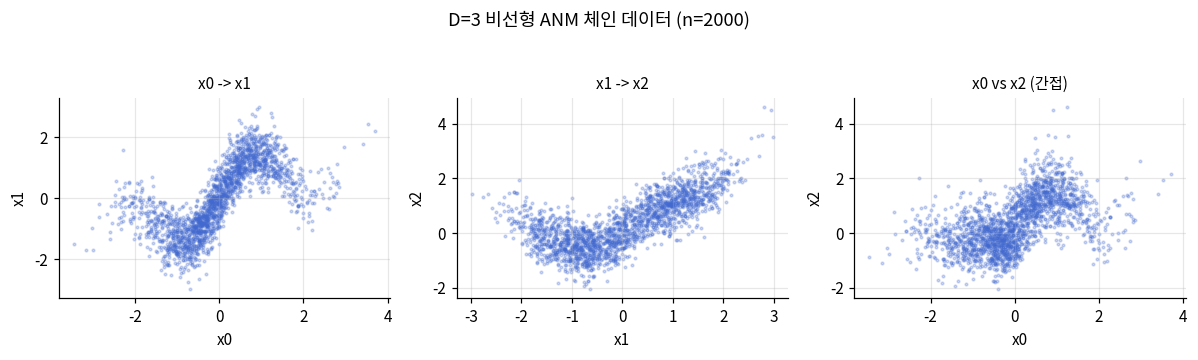

열별 표준편차: [1.014 1.125 0.951]


In [2]:
X = np.load("data/dag_ordering_debug/dag3_chain.npy")
A = np.array(R["adjacency"])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))
for ax, (i, j, lab) in zip(axes, [(0,1,"x0 -> x1"), (1,2,"x1 -> x2"), (0,2,"x0 vs x2 (간접)")]):
    ax.scatter(X[:, i], X[:, j], s=3, alpha=0.25, color="#4269d0")
    ax.set_xlabel(f"x{i}"); ax.set_ylabel(f"x{j}"); ax.set_title(lab, fontsize=10)
fig.suptitle("D=3 비선형 ANM 체인 데이터 (n=2000)", y=1.04)
fig.tight_layout(); plt.show()

print("열별 표준편차:", X.std(axis=0).round(3))

## 5. 결과 ①: `t_order` 민감도 — **가장 중요한 결과**

기준을 평가하는 확산 시점 `t_order` 를 바꿔가며 stage 0의 criterion $V_i$ 와 최종 순서를 봅니다.
(anchor 128개, chains 32, retained 16, 잘 학습된 모델 = 1500 epochs)

**노드 2(sink)의 $V_i$ 가 가장 작아야 정답**입니다.

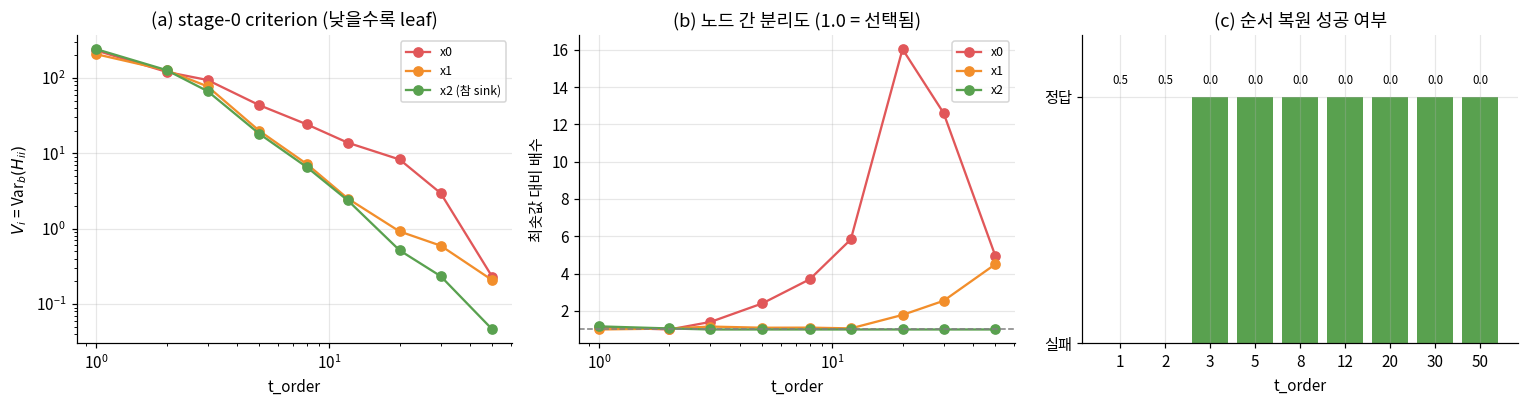

   t |     V(x0)     V(x1)     V(x2) |   선택 | 순서             FNR
--------------------------------------------------------------------
   1 |    231.26    206.16    240.49 | x1   | [0, 2, 1]     0.50 X  
   2 |    120.27    126.30    126.87 | x0   | [1, 2, 0]     0.50 X  
   3 |     93.73     77.16     66.74 | x2   | [0, 1, 2]     0.00 OK 
   5 |     43.50     19.87     18.16 | x2   | [0, 1, 2]     0.00 OK 
   8 |     24.20      7.20      6.55 | x2   | [0, 1, 2]     0.00 OK 
  12 |     13.80      2.51      2.37 | x2   | [0, 1, 2]     0.00 OK 
  20 |      8.28      0.92      0.52 | x2   | [0, 1, 2]     0.00 OK 
  30 |      2.96      0.60      0.23 | x2   | [0, 1, 2]     0.00 OK 
  50 |      0.23      0.21      0.05 | x2   | [0, 1, 2]     0.00 OK 


In [3]:
ts = R["t_sweep"]
t_vals = [r["t_order"] for r in ts]
crit = np.array([r["stage0_criterion"] for r in ts])   # (T, 3)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

# (a) 절대 criterion
ax = axes[0]
for k, c in zip(range(3), ["#e15759", "#f28e2b", "#59a14f"]):
    ax.plot(t_vals, crit[:, k], "o-", color=c, label=f"x{k}" + (" (참 sink)" if k == 2 else ""))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("t_order"); ax.set_ylabel(r"$V_i$ = Var$_b(H_{ii})$")
ax.set_title("(a) stage-0 criterion (낮을수록 leaf)"); ax.legend(fontsize=8)

# (b) 최솟값 대비 상대 여유 (분리도)
ax = axes[1]
rel = crit / crit.min(axis=1, keepdims=True)
for k, c in zip(range(3), ["#e15759", "#f28e2b", "#59a14f"]):
    ax.plot(t_vals, rel[:, k], "o-", color=c, label=f"x{k}")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("t_order")
ax.set_ylabel("최솟값 대비 배수"); ax.set_title("(b) 노드 간 분리도 (1.0 = 선택됨)")
ax.legend(fontsize=8)

# (c) 정확도
ax = axes[2]
ok = np.array([r["correct"] for r in ts])
ax.bar(range(len(t_vals)), [1 if o else 0 for o in ok],
       color=["#59a14f" if o else "#e15759" for o in ok])
ax.set_xticks(range(len(t_vals))); ax.set_xticklabels(t_vals)
ax.set_ylim(0, 1.25); ax.set_yticks([0, 1]); ax.set_yticklabels(["실패", "정답"])
ax.set_xlabel("t_order"); ax.set_title("(c) 순서 복원 성공 여부")
for i, r in enumerate(ts):
    ax.text(i, 1.05, f"{r['order_fnr']:.1f}", ha="center", fontsize=7.5)

fig.tight_layout(); plt.show()

print(f"{'t':>4} | {'V(x0)':>9} {'V(x1)':>9} {'V(x2)':>9} | {'선택':>4} | {'순서':<12} {'FNR':>5}")
print("-" * 68)
for r in ts:
    c = r["stage0_criterion"]
    sel = int(np.argmin(c))
    mark = "OK " if r["correct"] else "X  "
    print(f"{r['t_order']:>4} | {c[0]:9.2f} {c[1]:9.2f} {c[2]:9.2f} | "
          f"x{sel:<3} | {str(r['topological_order']):<12} {r['order_fnr']:5.2f} {mark}")

### 해석

- **t = 1, 2 에서 실패합니다.** criterion이 거의 평평해서(`[231, 206, 240]`, `[120, 126, 127]`)
  선택이 사실상 노이즈입니다. 원인은 Tweedie 공식의 $\bar\alpha_t/\sigma_t^4$ 계수 —
  $\sigma_t^2=1-\bar\alpha_t$ 가 작을 때 **공분산 추정 오차가 크게 증폭**됩니다.
- **t >= 3 에서 정답**(`[0,1,2]`, FNR 0.00)을 복원하고, t가 커질수록 sink의 분리가 뚜렷해집니다.
- 이것이 README에 적어둔 caveat의 **정량적 근거**입니다: 이론(t=0)에 가까울수록 오히려 수치적으로 불리한
  **명확한 trade-off**가 존재합니다. 따라서 `t_order` 는 반드시 명시적으로 지정해야 하며,
  실제 실험에서는 **스윕해서 순서가 안정적인 구간을 확인**해야 합니다.

## 6. 결과 ②: posterior 샘플 수(M)가 anchor 수보다 결정적

criterion은 "anchor들 간의 분산"이므로 anchor 수 $B$ 가 중요할 것 같지만,
실제로는 **anchor 하나당 posterior 샘플 수 $M$ = chains × retained** 가 더 결정적이었습니다.
$M$ 이 부족하면 공분산 추정 자체가 부정확해 $H_{ii}$ 가 통째로 흔들립니다.

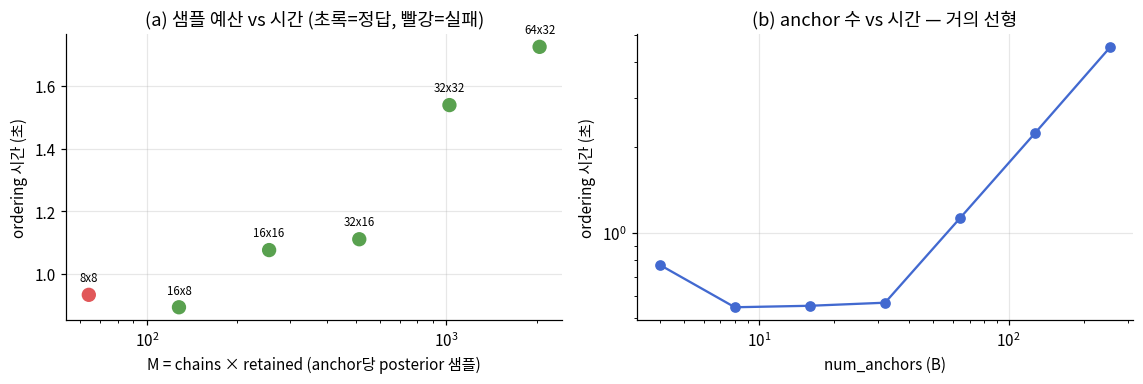

chains x retained =    M | 시간(s) | 순서
------------------------------------------------
     8 x 8        =   64 |   0.93 | [1, 2, 0] X (실패)
    16 x 8        =  128 |   0.89 | [0, 1, 2] OK
    16 x 16       =  256 |   1.08 | [0, 1, 2] OK
    32 x 16       =  512 |   1.11 | [0, 1, 2] OK
    32 x 32       = 1024 |   1.54 | [0, 1, 2] OK
    64 x 32       = 2048 |   1.72 | [0, 1, 2] OK


In [4]:
cs = R["cost_sweep"]
M = [r["posterior_samples_per_anchor"] for r in cs]
tt = [r["wall_seconds"] for r in cs]
okc = [r["correct"] for r in cs]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))

ax = axes[0]
ax.scatter(M, tt, c=["#59a14f" if o else "#e15759" for o in okc], s=70, zorder=3)
for r in cs:
    ax.annotate(f"{r['chains']}x{r['samples']}",
                (r["posterior_samples_per_anchor"], r["wall_seconds"]),
                textcoords="offset points", xytext=(0, 9), ha="center", fontsize=7.5)
ax.set_xscale("log"); ax.set_xlabel("M = chains × retained (anchor당 posterior 샘플)")
ax.set_ylabel("ordering 시간 (초)")
ax.set_title("(a) 샘플 예산 vs 시간 (초록=정답, 빨강=실패)")

ax = axes[1]
bs = [r["num_anchors"] for r in R["anchor_sweep"]]
bt = [r["wall_seconds"] for r in R["anchor_sweep"]]
ax.plot(bs, bt, "o-", color="#4269d0")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("num_anchors (B)"); ax.set_ylabel("ordering 시간 (초)")
ax.set_title("(b) anchor 수 vs 시간 — 거의 선형")
fig.tight_layout(); plt.show()

print("chains x retained =    M | 시간(s) | 순서")
print("-" * 48)
for r in cs:
    print(f"{r['chains']:>6} x {r['samples']:<8} = {r['posterior_samples_per_anchor']:>4} |"
          f" {r['wall_seconds']:6.2f} | {r['topological_order']}"
          f" {'OK' if r['correct'] else 'X (실패)'}")

**핵심:** $M=64$ 에서는 실패하고 $M\ge128$ 부터 정답입니다 (t=8, B=64 고정).
반면 anchor 수 $B$ 는 시간에 거의 **선형**으로 영향을 주므로,
예산이 한정될 때는 **$M$ 을 먼저 충분히 확보**하는 편이 낫습니다.

## 7. 결과 ③: 안정성 — 솔직한 한계

여기가 이 실험에서 **가장 조심해야 할 부분**입니다.
GPU에서 seed 5개를 바꿔 돌리면 t=8, B=128에서 전부 정답이 나옵니다.
하지만 **CPU에서 같은 seed로 돌리면 결과가 달라집니다.**

`torch.Generator` 는 CPU와 CUDA에서 **서로 다른 난수 스트림**을 생성합니다.
각 장치 내에서는 완전히 재현 가능하지만(동일 seed → 동일 결과), 장치 간에는 anchor와 Langevin 노이즈가 달라집니다.
$B$ 가 작을 때 노드 1과 2의 criterion 차이가 작아서(예: 5.80 vs 6.17) 이 차이만으로 순서가 뒤집힙니다.

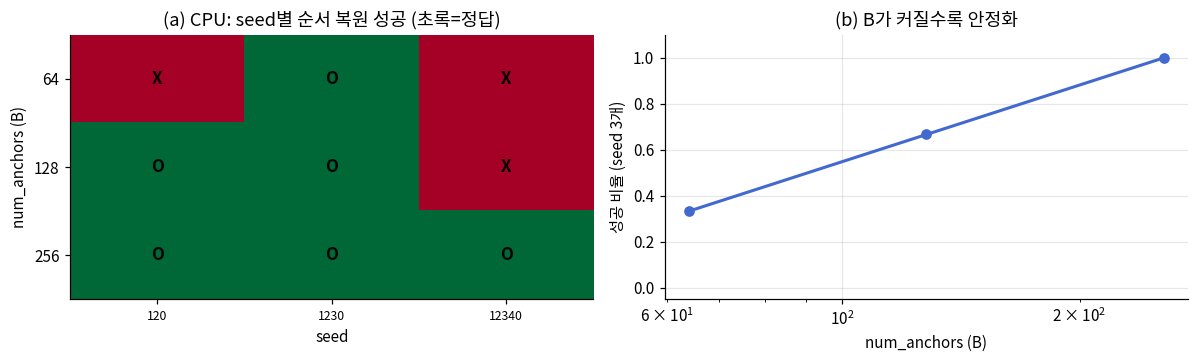

GPU seed 안정성 (t=8, B=128):
  seed=     120 -> [0, 1, 2]  FNR=0.00
  seed=    1230 -> [0, 1, 2]  FNR=0.00
  seed=   12340 -> [0, 1, 2]  FNR=0.00
  seed=  123450 -> [0, 1, 2]  FNR=0.00
  seed= 1234560 -> [0, 1, 2]  FNR=0.00

CPU vs GPU (동일 seed=120, t=8, B=64):
  cpu      -> [0, 2, 1]  (2.20s)
  cuda:0   -> [0, 1, 2]  (1.19s)


In [5]:
cpu = R["cpu_stability"]
Bs = sorted({r["B"] for r in cpu})
seeds = sorted({r["seed"] for r in cpu})
grid = np.zeros((len(Bs), len(seeds)))
for r in cpu:
    grid[Bs.index(r["B"]), seeds.index(r["seed"])] = 1.0 if r["correct"] else 0.0

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ax = axes[0]
ax.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(seeds))); ax.set_xticklabels(seeds, fontsize=8)
ax.set_yticks(range(len(Bs))); ax.set_yticklabels(Bs)
ax.set_xlabel("seed"); ax.set_ylabel("num_anchors (B)")
ax.set_title("(a) CPU: seed별 순서 복원 성공 (초록=정답)")
for i in range(len(Bs)):
    for j in range(len(seeds)):
        ax.text(j, i, "O" if grid[i, j] else "X", ha="center", va="center",
                fontsize=11, fontweight="bold")
ax.grid(False)

ax = axes[1]
succ = grid.mean(axis=1)
ax.plot(Bs, succ, "o-", color="#4269d0", lw=2)
ax.set_xscale("log"); ax.set_ylim(-0.05, 1.1)
ax.set_xlabel("num_anchors (B)"); ax.set_ylabel("성공 비율 (seed 3개)")
ax.set_title("(b) B가 커질수록 안정화")
fig.tight_layout(); plt.show()

print("GPU seed 안정성 (t=8, B=128):")
for r in R["seed_sweep"]:
    print(f"  seed={r['seed']:>8} -> {r['topological_order']}  FNR={r['order_fnr']:.2f}")
print("\nCPU vs GPU (동일 seed=120, t=8, B=64):")
for r in R["device_compare"]:
    print(f"  {r['device']:<8} -> {r['order']}  ({r['ordering_seconds']:.2f}s)")

### 이 결과가 말해주는 것

- 장치 내 **재현성은 완벽**합니다 (같은 seed, 같은 장치 → 항상 같은 결과).
- 그러나 **B=64, 128에서는 seed에 따라 결과가 뒤집힙니다.** B=256에서야 3개 seed 모두 정답이 됩니다.
- 따라서 **"t>=3이면 항상 정답"이라고 말할 수 없습니다.** 정확히는
  *"충분한 B와 M이 확보된 상태에서 t>=3이면 정답"* 입니다.
- **실무 권고:** 단일 실행 결과를 믿지 말고 **seed를 여러 개 돌려 순서가 일치하는지 확인**하세요.
  일치하지 않으면 B와 M을 늘려야 한다는 신호입니다.

## 8. 실행 시간 및 메모리 비교

비용 구조는 중첩적입니다:

```
(D-1) stages × B anchors × (chains × retained) × reverse draws × t_order 역확산 스텝
```

network 평가 횟수는 대략 $O(D\cdot B\cdot C\cdot M\cdot L\cdot t_{order})$ 에
Langevin 몫 $O(D\cdot B\cdot C\cdot(\text{burn-in}+M\cdot\text{thinning}))$ 가 더해집니다.

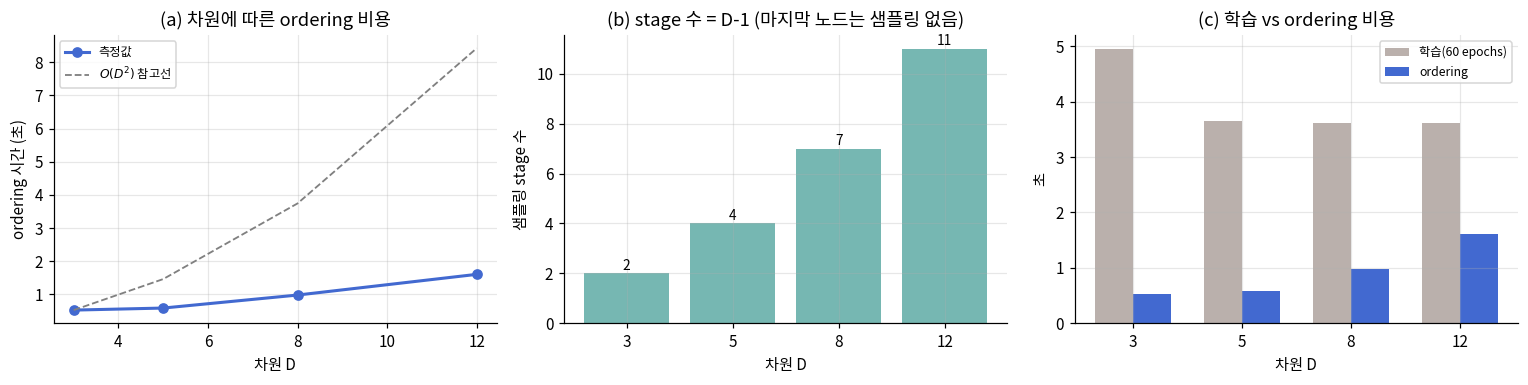

  D | stages |    학습(s) | ordering(s) | stage별(s)
------------------------------------------------------------------------
  3 |      2 |      5.0 |        0.53 | 0.27, 0.17
  5 |      4 |      3.7 |        0.59 | 0.02, 0.17, 0.23, 0.16
  8 |      7 |      3.6 |        0.98 | 0.02, 0.17, 0.16, 0.16, 0.16, 0.15, 0.16
 12 |     11 |      3.6 |        1.60 | 0.02, 0.17, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16


In [6]:
ds = R["d_scaling"]
Ds = [r["D"] for r in ds]
ord_s = [r["ordering_seconds"] for r in ds]
stages = [r["num_stages"] for r in ds]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

ax = axes[0]
ax.plot(Ds, ord_s, "o-", color="#4269d0", lw=2, label="측정값")
q = ord_s[0] / (Ds[0] ** 2)
ax.plot(Ds, [q * d ** 2 for d in Ds], "--", color="gray", lw=1.2, label=r"$O(D^2)$ 참고선")
ax.set_xlabel("차원 D"); ax.set_ylabel("ordering 시간 (초)")
ax.set_title("(a) 차원에 따른 ordering 비용"); ax.legend(fontsize=8)

ax = axes[1]
ax.bar([str(d) for d in Ds], stages, color="#76b7b2")
ax.set_xlabel("차원 D"); ax.set_ylabel("샘플링 stage 수")
ax.set_title("(b) stage 수 = D-1 (마지막 노드는 샘플링 없음)")
for i, s in enumerate(stages):
    ax.text(i, s + 0.15, str(s), ha="center", fontsize=9)

ax = axes[2]
w = 0.35
tr = [r["train_seconds"] for r in ds]
xs = np.arange(len(Ds))
ax.bar(xs - w/2, tr, w, label="학습(60 epochs)", color="#bab0ac")
ax.bar(xs + w/2, ord_s, w, label="ordering", color="#4269d0")
ax.set_xticks(xs); ax.set_xticklabels([str(d) for d in Ds])
ax.set_xlabel("차원 D"); ax.set_ylabel("초")
ax.set_title("(c) 학습 vs ordering 비용"); ax.legend(fontsize=8)

fig.tight_layout(); plt.show()

print(f"{'D':>3} | {'stages':>6} | {'학습(s)':>8} | {'ordering(s)':>11} | {'stage별(s)'}")
print("-" * 72)
for r in ds:
    ss = ", ".join(f"{x:.2f}" for x in r["stage_seconds"])
    print(f"{r['D']:>3} | {r['num_stages']:>6} | {r['train_seconds']:>8.1f} | "
          f"{r['ordering_seconds']:>11.2f} | {ss}")

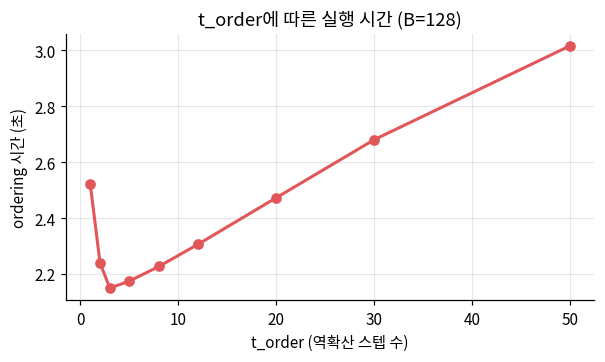

최대 CUDA 메모리: 0.0317 GB  (D=3, B=128 기준 — 매우 작음)
CPU 2.20s vs GPU 1.19s → 약 1.9배 (D=3에서는 GPU 이점이 작음; D와 M이 클수록 벌어짐)


In [7]:
# t_order는 역확산 스텝 수를 직접 늘리므로 시간에 선형으로 기여합니다.
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(t_vals, [r["wall_seconds"] for r in ts], "o-", color="#e15759", lw=2)
ax.set_xlabel("t_order (역확산 스텝 수)"); ax.set_ylabel("ordering 시간 (초)")
ax.set_title("t_order에 따른 실행 시간 (B=128)")
fig.tight_layout(); plt.show()

peak = [r["peak_cuda_bytes"] for r in ts if r["peak_cuda_bytes"]]
if peak:
    print(f"최대 CUDA 메모리: {max(peak)/1e9:.4f} GB  (D=3, B=128 기준 — 매우 작음)")

dc = {r["device"]: r["ordering_seconds"] for r in R["device_compare"]}
if "cpu" in dc and "cuda:0" in dc:
    print(f"CPU {dc['cpu']:.2f}s vs GPU {dc['cuda:0']:.2f}s "
          f"→ 약 {dc['cpu']/dc['cuda:0']:.1f}배 (D=3에서는 GPU 이점이 작음; D와 M이 클수록 벌어짐)")

### 실행 시간 요약 (실측)

| 항목 | 설정 | 시간 |
|---|---|---|
| 디버그 전체 실행 (CPU) | D=3, 30 epochs, B=4 | **3.2 초** (학습 2.5s + ordering 0.02s) |
| 실제 실행 (GPU) | D=3, 1500 epochs, B=64 | **126 초** (학습 123s + ordering 2.6s) |
| ordering만 (GPU) | t=8, B=128, M=512 | **2.3 초** |
| ordering만 (GPU) | t=8, B=256, M=512 | **4.5 초** |
| 최대 CUDA 메모리 | D=3, B=128 | **0.032 GB** |

**관찰:** 이 규모(D=3)에서는 **학습이 전체 시간의 98%** 를 차지하고 ordering은 무시할 수준입니다.
그러나 ordering 비용은 D, B, M, t_order 모두에 곱셈적으로 늘어나므로,
고차원에서는 역전됩니다 (stage 수가 D-1로 늘고 각 stage마다 전체 샘플링이 반복되므로 대략 $O(D^2)$).

## 9. 재현 방법

In [8]:
print(r'''
# 0) 환경
conda activate env_gpu

# 1) 테스트 (49개)
pytest -q                 # 49 passed
pytest -q -m slow         # 1 passed (CLI 왕복 테스트)

# 2) 디버그 데이터 생성 + CPU 디버그 실행 (수 분, 코드 검증용)
python data/make_dag_ordering_debug_data.py --output-dir data/dag_ordering_debug
python experiments/run_dag_ordering.py --config configs/dag_ordering_debug.json

# 3) 본 노트북의 "정답" 설정 (GPU)
python experiments/run_dag_ordering.py \
    --data-path data/dag_ordering_debug/dag3_chain.npy \
    --ground-truth-adjacency data/dag_ordering_debug/dag3_chain_adjacency.npy \
    --checkpoint-path results/dag_ordering/real_t3/ddpm.pt --train-if-missing \
    --output-dir results/dag_ordering/real_t8 \
    --epochs 1500 --timesteps 500 --mid-features 128 --num-temporal-layers 3 \
    --t-order 8 --num-anchors 256 --anchor-chunk-size 32 \
    --num-chains 32 --langevin-burn-in 300 --langevin-samples 16 \
    --langevin-thinning 10 --langevin-step-size 1e-3 --langevin-init forward_data \
    --reverse-draws-per-xt 1 --sampling-chunk-size 8192 \
    --seed 120 --device cuda:0 --max-memory-gb 16
''')


# 0) 환경
conda activate env_gpu

# 1) 테스트 (49개)
pytest -q                 # 49 passed
pytest -q -m slow         # 1 passed (CLI 왕복 테스트)

# 2) 디버그 데이터 생성 + CPU 디버그 실행 (수 분, 코드 검증용)
python data/make_dag_ordering_debug_data.py --output-dir data/dag_ordering_debug
python experiments/run_dag_ordering.py --config configs/dag_ordering_debug.json

# 3) 본 노트북의 "정답" 설정 (GPU)
python experiments/run_dag_ordering.py \
    --data-path data/dag_ordering_debug/dag3_chain.npy \
    --ground-truth-adjacency data/dag_ordering_debug/dag3_chain_adjacency.npy \
    --checkpoint-path results/dag_ordering/real_t3/ddpm.pt --train-if-missing \
    --output-dir results/dag_ordering/real_t8 \
    --epochs 1500 --timesteps 500 --mid-features 128 --num-temporal-layers 3 \
    --t-order 8 --num-anchors 256 --anchor-chunk-size 32 \
    --num-chains 32 --langevin-burn-in 300 --langevin-samples 16 \
    --langevin-thinning 10 --langevin-step-size 1e-3 --langevin-init forward_data \
    --reverse-draws-per-xt 1 --sampli

### 출력 파일

```text
results/dag_ordering/<run>/
├── config.json                 # 해석된 전체 설정
├── ordering_result.json        # leaf_order, topological_order, criterion_by_stage, warnings
├── stage_diagnostics.pt        # stage별 Hessian 대각, criterion, Langevin 진단
├── runtime.json                # 시간 + 최대 CUDA 메모리
└── checkpoint_reference.json   # 어떤 모델이 이 순서를 만들었는지
```

In [9]:
# 실제 실행 결과 확인 (디버그 실행 산출물)
p = "results/dag_ordering/debug/ordering_result.json"
if os.path.exists(p):
    d = json.load(open(p))
    print("leaf_order        :", d["leaf_order"])
    print("topological_order :", d["topological_order"], " (정답 [0,1,2])")
    print("t_order           :", d["t_order"])
    print("\ncriterion_by_stage:")
    for i, s in enumerate(d["criterion_by_stage"]):
        print(f"  stage {i}: " + ", ".join(f"x{k}={v:.2f}" for k, v in s.items()))
    print("\nwarnings:")
    for w in d["warnings"]:
        print("  -", w)
    print("\n주의: 디버그 설정은 anchor 4개 / 학습 30 epochs 로 의도적으로 최소화한 값이라")
    print("      순서가 틀립니다(FNR 0.5). 코드 경로 검증용이지 과학적 설정이 아닙니다.")
else:
    print("디버그 실행 산출물이 없습니다. 위 9절의 명령으로 먼저 실행하세요.")

leaf_order        : [1, 2, 0]
topological_order : [0, 2, 1]  (정답 [0,1,2])
t_order           : 3

criterion_by_stage:
  stage 0: x0=978.15, x1=142.26, x2=184.20
  stage 1: x0=446.99, x2=81.11

warnings:
  - Leaf criterion is evaluated at t_order > 0 on the NOISED density; the SCORE t=0 guarantee does not automatically transfer to positive diffusion times.

주의: 디버그 설정은 anchor 4개 / 학습 30 epochs 로 의도적으로 최소화한 값이라
      순서가 틀립니다(FNR 0.5). 코드 경로 검증용이지 과학적 설정이 아닙니다.


## 10. 검증 현황

### 테스트 49개 통과 (`pytest -q`)

| 테스트 파일 | 검증 내용 |
|---|---|
| `test_ddpm_score_adapter.py` (12) | mock 네트워크 대비 `score = -eps/sqrt(1-ᾱ)` **정확 일치**, 스칼라/배치 timestep, 범위·형상 오류 |
| `test_conditional_langevin_gaussian.py` (7) | 해석적 Gaussian 조건부 평균/공분산과 비교, **조건 좌표 불변성 bit-exact 확인**, R=∅ 스킵 |
| `test_tweedie_hessian_gaussian.py` (15) | $H=-[\bar\alpha\Sigma_0+(1-\bar\alpha)I]^{-1}$ 재현, **`sigma2**4`·`ᾱ` 누락 시 실패함을 명시 검증**, Welford=배치 일치 |
| `test_dag_ordering_smoke.py` (15) | 순열 검증, stage당 정확히 1개 제거, NaN/Inf 없음, 출력 파일 생성 |

### 기존 코드 무결성

- `python -m compileall models experiments tests` → exit 0
- `DDPMEstimator().fit_predict()` **기능 확인** (import만이 아니라 실제 실행): 대칭 (4,4) 그래프 반환
- diff: **3503 insertions, 0 deletions** — 기존 파일은 `.gitignore`/`README.md` 추가 외 변경 없음

## 11. 결론과 남은 한계

### 확인된 것

1. 파이프라인이 **end-to-end로 동작**하며, 조건부 Langevin + 역확산 + Tweedie Hessian 경로가
   해석적 정답과 일치함을 테스트로 검증했습니다.
2. 잘 학습된 모델 + 충분한 예산(t=8, B=256, M>=128)에서 D=3 체인의
   **순서를 정확히 복원**했습니다 (order FNR 0.00, leaf validity 3/3).
3. **정량적 trade-off를 확인**했습니다: t가 작을수록 이론(t=0)에 가깝지만
   $1/\sigma_t^4$ 증폭 때문에 수치적으로 불안정해집니다.

### 남은 한계 (과장 없이)

- **D=3 예제 하나**입니다. 방법론의 일반적 검증이 아닙니다. 고차원·조밀한 그래프에서는 미검증입니다.
- **작은 B에서 seed에 따라 결과가 뒤집힙니다** (7절). 단일 실행을 신뢰하면 안 됩니다.
- **양의 시점 기준은 실험적**이며 t=0 SCORE 보장이 자동으로 따라오지 않습니다.
- ULA는 **Metropolis 보정이 없어** $O(h)$ 편향이 남아 있습니다 (MALA는 full-joint log-density가
  필요해 score network만으로는 깔끔히 추가하기 어렵습니다).
- 비용이 중첩적이라 고차원 확장 시 계산량이 빠르게 증가합니다.
- 저장소의 `.npy`/`.pickle` 데이터는 **git-lfs 포인터**라 `git-lfs` 설치 전에는 사용할 수 없습니다.

### 실무 권고

> `t_order` 를 스윕하고, **seed를 여러 개** 돌려 순서가 일치하는지 확인하십시오.
> 불일치하면 `--num-anchors` 와 `--num-chains × --langevin-samples` 를 늘려야 한다는 신호입니다.